
# Notebook 3 — Continuous-Time Constant-Mix Strategies

This notebook validates Chapter 5's closed-form results:

- **Proposition 5.1**: the closed-form AVaR of the terminal log-return of
  a continuously-rebalanced constant-mix strategy, checked against an
  *exact* Monte Carlo simulation (no discretisation error: each path is
  drawn directly from the exact solution of the constant-mix wealth SDE).
- **Theorem 5.1**: the AVaR-optimal constant-mix proportion
  $\pi^*(\lambda, T) = \frac{\mu-r}{\sigma^2} - \frac{\kappa(\lambda)}{\sigma\sqrt{T}}$,
  checked as the numerical minimiser of the closed-form AVaR curve, and
  its two limiting behaviours (correction vanishing as $T\to\infty$ or
  $\lambda \to 1$).


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from convexrisk.continuous_time import (
    log_return_moments, closed_form_avar, optimal_constant_mix,
    simulate_terminal_log_return,
)
from convexrisk.risk_measures import empirical_avar, kappa

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(2026)



## 1. Closed form vs. exact Monte Carlo, across proportions $\pi$


In [2]:

mu, r, sigma, T, level = 0.10, 0.02, 0.20, 1.0, 0.05
n_paths = 3_000_000

pis = np.linspace(-0.5, 2.5, 25)
closed_form = np.array([closed_form_avar(pi, mu, r, sigma, T, level) for pi in pis])
monte_carlo = np.empty_like(pis)
for i, pi in enumerate(pis):
    samples = simulate_terminal_log_return(pi, mu, r, sigma, T, n_paths, rng)
    monte_carlo[i] = empirical_avar(samples, level)

max_abs_error = np.max(np.abs(closed_form - monte_carlo))
max_rel_error = np.max(np.abs(closed_form - monte_carlo) / np.abs(closed_form))
print(f"Max absolute error (closed form vs. MC, n={n_paths}): {max_abs_error:.5f}")
print(f"Max relative error: {max_rel_error*100:.2f}%")


Max absolute error (closed form vs. MC, n=3000000): 0.00081
Max relative error: 0.24%


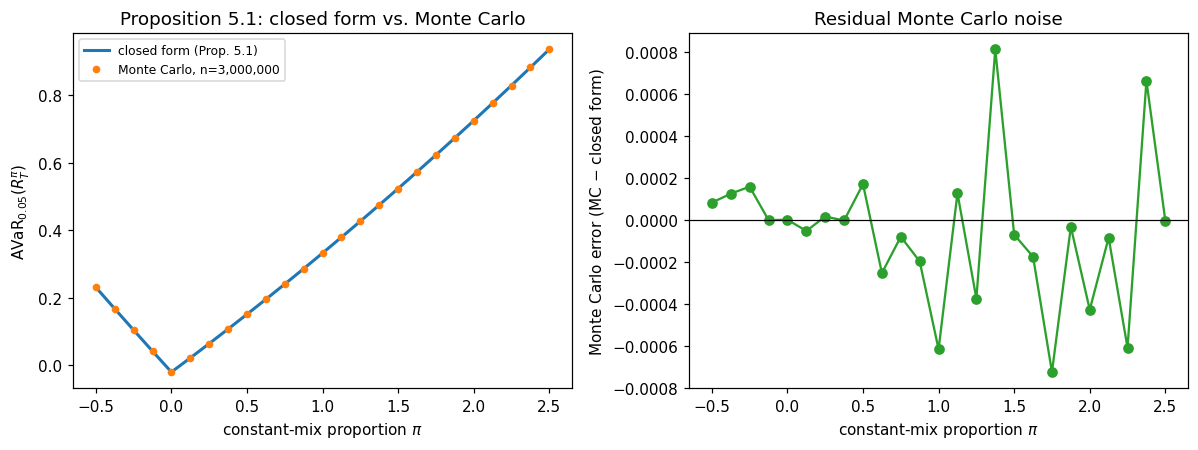

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(pis, closed_form, "-", label="closed form (Prop. 5.1)", color="C0", linewidth=2)
axes[0].plot(pis, monte_carlo, "o", label=f"Monte Carlo, n={n_paths:,}", color="C1", markersize=4)
axes[0].set_xlabel(r"constant-mix proportion $\pi$")
axes[0].set_ylabel(r"$\mathrm{AVaR}_{0.05}(R_T^\pi)$")
axes[0].set_title("Proposition 5.1: closed form vs. Monte Carlo")
axes[0].legend(fontsize=8)

axes[1].plot(pis, (monte_carlo - closed_form), "o-", color="C2")
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set_xlabel(r"constant-mix proportion $\pi$")
axes[1].set_ylabel("Monte Carlo error (MC $-$ closed form)")
axes[1].set_title("Residual Monte Carlo noise")

plt.tight_layout()
plt.savefig("fig_03_closed_form_vs_mc.png", dpi=140)
plt.show()



## 2. The optimal constant-mix proportion (Theorem 5.1)

We locate the minimiser of the closed-form AVaR curve numerically (fine
grid search) and compare it against the explicit formula
$\pi^* = \frac{\mu-r}{\sigma^2} - \frac{\kappa(\lambda)}{\sigma\sqrt{T}}$.


In [4]:

mu, r, sigma, T, level = 0.18, 0.02, 0.15, 5.0, 0.1  # interior-solution parameters

fine_pis = np.linspace(0.0, 4.0, 4000)
fine_avars = np.array([closed_form_avar(pi, mu, r, sigma, T, level) for pi in fine_pis])
pi_star_numeric = fine_pis[np.argmin(fine_avars)]
pi_star_formula = optimal_constant_mix(mu, r, sigma, T, level)

myopic = (mu - r) / sigma**2
correction = kappa(level) / (sigma * np.sqrt(T))

print(f"Merton myopic proportion        (mu-r)/sigma^2       = {myopic:.4f}")
print(f"risk-aversion correction        kappa(level)/(sigma*sqrt(T)) = {correction:.4f}")
print(f"pi* from Theorem 5.1 formula                          = {pi_star_formula:.4f}")
print(f"pi* from numerical grid search (step={fine_pis[1]-fine_pis[0]:.4f})   = {pi_star_numeric:.4f}")


Merton myopic proportion        (mu-r)/sigma^2       = 7.1111
risk-aversion correction        kappa(level)/(sigma*sqrt(T)) = 5.2323
pi* from Theorem 5.1 formula                          = 1.8788
pi* from numerical grid search (step=0.0010)   = 1.8785


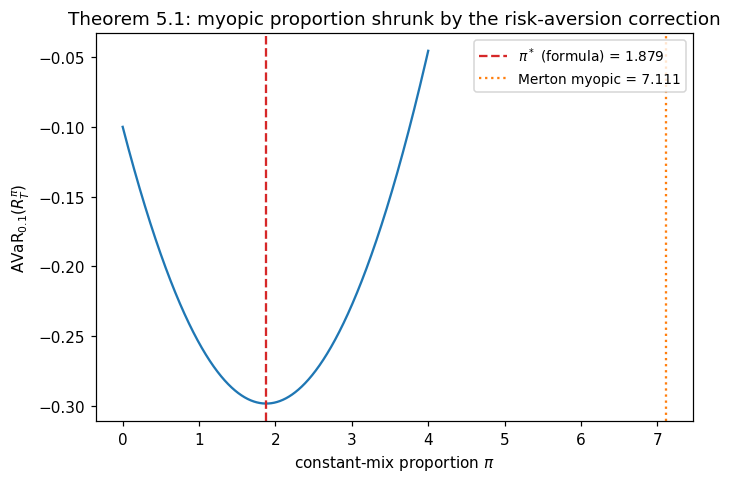

In [5]:

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(fine_pis, fine_avars, "-", color="C0")
ax.axvline(pi_star_formula, color="C3", linestyle="--",
           label=f"$\\pi^*$ (formula) = {pi_star_formula:.3f}")
ax.axvline(myopic, color="C1", linestyle=":", label=f"Merton myopic = {myopic:.3f}")
ax.set_xlabel(r"constant-mix proportion $\pi$")
ax.set_ylabel(r"$\mathrm{AVaR}_{0.1}(R_T^\pi)$")
ax.set_title("Theorem 5.1: myopic proportion shrunk by the risk-aversion correction")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_03_optimal_constant_mix.png", dpi=140)
plt.show()



## 3. Limiting behaviour of the correction

The correction $\kappa(\lambda)/(\sigma\sqrt{T})$ should vanish as
$T\to\infty$ (longer horizon dilutes tail risk relative to linear drift)
and as $\lambda\to 1$ ($\mathrm{AVaR}_1 = -\mathbb{E}[\cdot]$, the
risk-neutral limit, so no correction is needed).


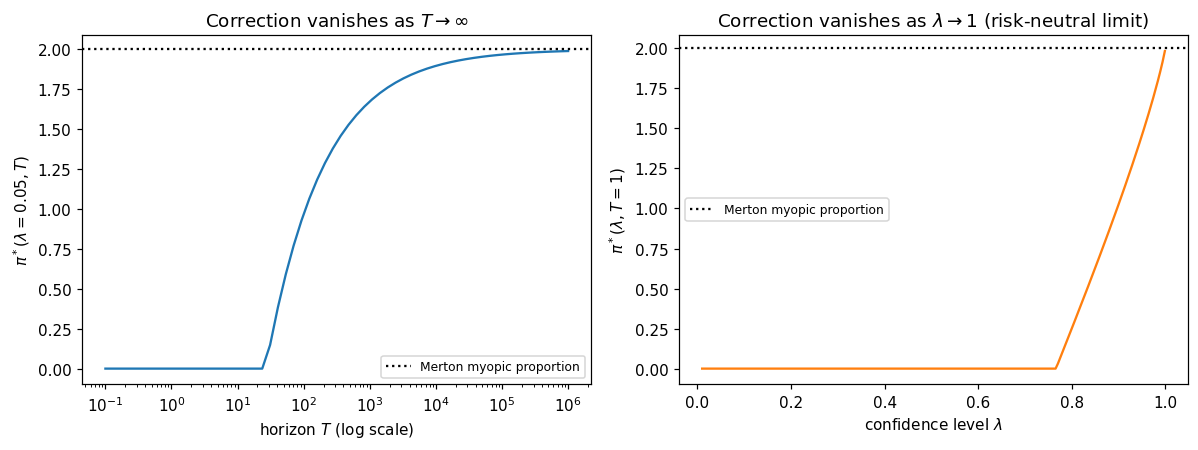

pi*(T=1e6) = 1.9897  vs. myopic = 2.0000
pi*(level=0.999) = 1.9831  vs. myopic = 2.0000


In [6]:

mu, r, sigma = 0.10, 0.02, 0.20
myopic = (mu - r) / sigma**2

horizons = np.logspace(-1, 6, 60)
pi_star_vs_T = np.array([optimal_constant_mix(mu, r, sigma, T, 0.05) for T in horizons])

levels = np.linspace(0.01, 0.999, 200)
pi_star_vs_level = np.array([optimal_constant_mix(mu, r, sigma, 1.0, lvl) for lvl in levels])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogx(horizons, pi_star_vs_T, color="C0")
axes[0].axhline(myopic, color="k", linestyle=":", label="Merton myopic proportion")
axes[0].set_xlabel("horizon $T$ (log scale)")
axes[0].set_ylabel(r"$\pi^*(\lambda=0.05, T)$")
axes[0].set_title(r"Correction vanishes as $T \to \infty$")
axes[0].legend(fontsize=8)

axes[1].plot(levels, pi_star_vs_level, color="C1")
axes[1].axhline(myopic, color="k", linestyle=":", label="Merton myopic proportion")
axes[1].set_xlabel(r"confidence level $\lambda$")
axes[1].set_ylabel(r"$\pi^*(\lambda, T=1)$")
axes[1].set_title(r"Correction vanishes as $\lambda \to 1$ (risk-neutral limit)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_03_limiting_behaviour.png", dpi=140)
plt.show()

print(f"pi*(T=1e6) = {pi_star_vs_T[-1]:.4f}  vs. myopic = {myopic:.4f}")
print(f"pi*(level=0.999) = {pi_star_vs_level[-1]:.4f}  vs. myopic = {myopic:.4f}")
